# IMU – Bradicinesia Global del Cuerpo (MDS-UPDRS 3.14)

**Paciente con Parkinson**

La prueba 3.14 del MDS-UPDRS evalúa la bradicinesia global del cuerpo:
lentitud, pobreza de movimiento, amplitud reducida y pausas.
Se observa al paciente sentado y se valora la espontaneidad del movimiento.

**Dispositivos:** BASE-SPINE, LEFT-HAND, RIGHT-HAND (se reutilizan datos de prueba 3.15).

**Escala MDS-UPDRS 3.14:**
| Score | Interpretación |
|-------|---------------|
| 0 | Normal |
| 1 | Ligera lentitud o disminución de espontaneidad |
| 2 | Lentitud y pobreza de movimiento evidentes |
| 3 | Lentitud y pobreza de movimiento marcada |
| 4 | Rigidez casi completa, mínimo movimiento voluntario |

Qué hace este notebook:
- Carga datos IMU y estima tasa de muestreo por dispositivo.
- Calcula métricas de bradicinesia: variabilidad, jerk, potencia de movimiento.
- Analiza PSD para separar movimiento voluntario (0.5–3 Hz) de temblor (3–8 Hz).
- Estima score MDS-UPDRS 3.14 basado en heurísticas sobre las señales.

In [1]:
# Imports y utilidades (con alternativas si SciPy no está)
from __future__ import annotations
import json
from typing import Dict, Tuple
import numpy as np
import pandas as pd

# Gráficos
try:
    import matplotlib.pyplot as plt
    plt.style.use("seaborn-v0_8")
    _USE_MPL = True
except Exception:
    _USE_MPL = False
    try:
        import plotly.graph_objects as go
    except Exception:
        go = None

# Señales: SciPy si existe; si no, alternativas con NumPy
try:
    import scipy.signal as sps
    _HAVE_SCIPY = True
except Exception:
    sps = None
    _HAVE_SCIPY = False

def np_welch(x: np.ndarray, fs: float, nperseg: int = 1024):
    x = np.asarray(x, dtype=float)
    if len(x) < 4:
        return np.array([0.0, 1.0]), np.array([0.0, 0.0])
    nperseg = int(min(nperseg, len(x)))
    if nperseg < 8:
        nperseg = max(8, len(x)//2)
    step = max(1, nperseg//2)
    win = np.hanning(nperseg)
    segs = []
    for start in range(0, len(x)-nperseg+1, step):
        seg = x[start:start+nperseg] - np.mean(x[start:start+nperseg])
        segs.append(seg*win)
    if not segs:
        seg = x - np.mean(x)
        win = np.hanning(len(seg))
        segs = [seg*win]
        nperseg = len(seg)
    segs = np.stack(segs, axis=0)
    X = np.fft.rfft(segs, axis=1)
    Pxx = (np.abs(X)**2) / (np.sum(win**2) * fs)
    Pxx = np.mean(Pxx, axis=0)
    f = np.fft.rfftfreq(nperseg, d=1.0/fs)
    return f, Pxx

def welch_psd(x: np.ndarray, fs: float, nperseg: int = 1024):
    if _HAVE_SCIPY:
        f, Pxx = sps.welch(x, fs=fs, nperseg=min(nperseg, len(x)), detrend='constant', scaling='density')
        return f, Pxx
    return np_welch(x, fs, nperseg)

def simple_bandpass(x: np.ndarray, fs: float, low: float, high: float) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    if len(x) < 8 or not np.isfinite(fs) or fs <= 0:
        return np.zeros_like(x)
    if _HAVE_SCIPY and high < fs/2:
        try:
            b, a = sps.butter(4, [low/(fs/2), high/(fs/2)], btype='bandpass')
            return sps.filtfilt(b, a, x, method='gust')
        except Exception:
            pass
    X = np.fft.rfft(x)
    f = np.fft.rfftfreq(len(x), d=1.0/fs)
    mask = (f >= low) & (f <= high)
    Xf = np.zeros_like(X)
    Xf[mask] = X[mask]
    return np.fft.irfft(Xf, n=len(x))

def trapz_power(f: np.ndarray, Pxx: np.ndarray) -> float:
    if f.size < 2 or Pxx.size < 2:
        return 0.0
    return float(np.trapz(Pxx, f))

In [2]:
# Carga de JSON y aplanado
from pathlib import Path

# Archivo reutilizado para la prueba 3.14 Bradicinesia (Parkinson)
json_path = Path("../Datos/Parkinson/3.15-Parkinson.json")
assert json_path.exists(), f"No se encontró el archivo: {json_path}"

with open(json_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

patient = data.get('patient', {})
test_type = data.get('testType', None)
imu_data = data.get('imuData', [])
print(f"Registros IMU: {len(imu_data)} | TestType: {test_type}")
print("Paciente:", patient)

rows = []
for p in imu_data:
    acc = p.get('accelerometer', {}) or {}
    gyr = p.get('gyroscope', {}) or {}
    rows.append({
        'deviceId': p.get('deviceId', 'UNKNOWN'),
        'timestamp_ms': p.get('timestamp', np.nan),
        'ax': acc.get('x', np.nan), 'ay': acc.get('y', np.nan), 'az': acc.get('z', np.nan),
        'gx': gyr.get('x', np.nan), 'gy': gyr.get('y', np.nan), 'gz': gyr.get('z', np.nan),
    })

df = pd.DataFrame(rows).dropna(subset=['timestamp_ms','deviceId']).sort_values(['deviceId','timestamp_ms']).reset_index(drop=True)
assert not df.empty, "El DataFrame de señales está vacío"
df.head()

Registros IMU: 2195 | TestType: GAIT_ARMS
Paciente: {'birthDate': '17/04/1967', 'id': '16751329', 'name': 'Luis Felipe Jojoa Lasso', 'observations': 'prueba Felipe Manos extendidas por 10 segundos Toma 2 correcta ignorar la primera porque no guardaba'}


,deviceId,timestamp_ms,ax,ay,az,gx,gy,gz
0,BASE-SPINE,186670,1.036987,-0.150513,-0.055664,-1.647949,-11.169430,-1.647949
1,BASE-SPINE,186696,1.034180,-0.142334,-0.052002,-1.037598,-7.812500,-1.464844
2,BASE-SPINE,186722,1.018921,-0.137573,-0.050171,-0.366211,-6.530762,-1.159668
3,BASE-SPINE,186748,1.031494,-0.140991,-0.044434,0.000000,-4.638672,-0.732422
4,BASE-SPINE,186775,1.017456,-0.141113,-0.056274,1.220703,-5.065918,-1.220703


In [3]:
# Preprocesamiento y ventana de 10 s
def estimate_fs_ms(t_ms: np.ndarray) -> float:
    t_ms = np.asarray(t_ms, dtype=float)
    if t_ms.size < 2:
        return float('nan')
    dt = np.diff(t_ms)/1000.0
    dt = dt[dt > 0]
    if dt.size == 0:
        return float('nan')
    med = np.median(dt)
    return float('inf') if med <= 0 else 1.0/med

df = df.copy()
df['t'] = df.groupby('deviceId')['timestamp_ms'].transform(lambda x: (x - x.iloc[0]) / 1000.0)
df['acc_mag'] = np.sqrt(df['ax']**2 + df['ay']**2 + df['az']**2)
df['gyro_mag'] = np.sqrt(df['gx']**2 + df['gy']**2 + df['gz']**2)

devices = list(df['deviceId'].dropna().unique())
fs_map: Dict[str, float] = {d: estimate_fs_ms(df.loc[df['deviceId']==d, 'timestamp_ms'].to_numpy()) for d in devices}
fs_map

# Ventana común de 10 s centrada si es posible
per_dev_max = df.groupby('deviceId')['t'].max()
per_dev_min = df.groupby('deviceId')['t'].min()
global_min = float(per_dev_min.max()) if not per_dev_min.empty else 0.0
global_max = float(per_dev_max.min()) if not per_dev_max.empty else 0.0
dur = max(0.0, global_max - global_min)
if dur >= 10.0:
    start_t = global_min + (dur - 10.0)/2.0
    end_t = start_t + 10.0
else:
    start_t = global_min
    end_t = global_max
print(f"Ventana seleccionada: [{start_t:.2f}, {end_t:.2f}] s (dur={end_t-start_t:.2f}s)")

mask = (df['t'] >= start_t) & (df['t'] <= end_t)
df_win = df.loc[mask].copy()
assert not df_win.empty, "No hay datos en la ventana seleccionada"
df_win.head()

Ventana seleccionada: [5.22, 15.22] s (dur=10.00s)


,deviceId,timestamp_ms,ax,ay,az,gx,gy,gz,t,acc_mag,gyro_mag
199,BASE-SPINE,191901,1.014526,-0.130859,-0.130981,-0.122070,-0.732422,-0.183105,5.231,1.031282,0.764768
200,BASE-SPINE,191927,1.010132,-0.129272,-0.128174,-0.061035,-1.770020,-0.427246,5.257,1.026405,1.821877
201,BASE-SPINE,191953,1.011597,-0.125244,-0.130859,0.000000,-1.831055,-0.488281,5.283,1.027686,1.895041
202,BASE-SPINE,191980,1.004761,-0.122192,-0.136108,-0.427246,-1.953125,-0.305176,5.310,1.021274,2.022466
203,BASE-SPINE,192006,1.003174,-0.128418,-0.136353,-0.488281,-2.136230,-0.183105,5.336,1.020510,2.198960


In [4]:
# Cálculo de métricas de bradicinesia por dispositivo
from dataclasses import dataclass

@dataclass
class BradykinesiaResult:
    device: str
    fs: float
    mean_acc_mag: float      # magnitud promedio aceleración (g)
    std_acc_mag: float       # variabilidad de movimiento
    mean_gyro_mag: float     # velocidad angular promedio (deg/s)
    std_gyro_mag: float
    rms_acc: float           # RMS de aceleración
    rms_gyro: float          # RMS de giroscopio
    peak_acc: float          # máx aceleración
    peak_gyro: float         # máx giroscopio
    mean_jerk: float         # jerk medio (derivada de aceleración)
    movement_power_ratio: float  # potencia en banda de movimiento voluntario (0.5–3 Hz) / total (0.5–15 Hz)
    bradykinesia_score: int  # estimación MDS-UPDRS 3.14 (0-4)

def compute_bradykinesia(acc_mag, gyro_mag, fs):
    # Calcula métricas de bradicinesia para una ventana de señal.
    if not np.isfinite(fs) or fs <= 0 or acc_mag.size < 20:
        return None

    # Métricas básicas
    mean_acc = float(np.mean(acc_mag))
    std_acc = float(np.std(acc_mag))
    mean_gyro = float(np.mean(gyro_mag))
    std_gyro = float(np.std(gyro_mag))
    rms_acc = float(np.sqrt(np.mean(acc_mag**2)))
    rms_gyro = float(np.sqrt(np.mean(gyro_mag**2)))
    peak_acc = float(np.max(np.abs(acc_mag - np.mean(acc_mag))))
    peak_gyro = float(np.max(np.abs(gyro_mag - np.mean(gyro_mag))))

    # Jerk (derivada temporal de la magnitud de aceleración)
    jerk = np.diff(acc_mag) * fs  # aproximación de da/dt
    mean_jerk = float(np.mean(np.abs(jerk)))

    # Potencia en banda de movimiento voluntario (0.5-3 Hz) vs total (0.5-15 Hz)
    f, Pxx = welch_psd(acc_mag - np.mean(acc_mag), fs=fs, nperseg=min(1024, max(128, int(fs*2))))
    mov_mask = (f >= 0.5) & (f <= 3.0)
    full_mask = (f >= 0.5) & (f <= 15.0)
    mov_power = trapz_power(f[mov_mask], Pxx[mov_mask])
    full_power = trapz_power(f[full_mask], Pxx[full_mask])
    mov_ratio = mov_power / full_power if full_power > 0 else 0.0

    # Heurística de score MDS-UPDRS 3.14 (bradicinesia global)
    # Se basa en la variabilidad y amplitud de movimiento
    # Valores bajos de variabilidad + amplitud => mayor bradicinesia
    # (paciente sano: movimiento amplio y variado; parkinson: movimiento reducido)
    movement_energy = std_acc + std_gyro / 50.0  # normalizado
    if movement_energy > 0.4:
        score = 0  # Normal – sin evidencia de lentitud
    elif movement_energy > 0.25:
        score = 1  # Leve – ligera lentitud global
    elif movement_energy > 0.12:
        score = 2  # Moderado – lentitud global evidente
    elif movement_energy > 0.05:
        score = 3  # Severo – lentitud marcada
    else:
        score = 4  # Muy severo – apenas hay movimiento voluntario

    return BradykinesiaResult(
        device='', fs=fs, mean_acc_mag=mean_acc, std_acc_mag=std_acc,
        mean_gyro_mag=mean_gyro, std_gyro_mag=std_gyro,
        rms_acc=rms_acc, rms_gyro=rms_gyro,
        peak_acc=peak_acc, peak_gyro=peak_gyro,
        mean_jerk=mean_jerk, movement_power_ratio=mov_ratio,
        bradykinesia_score=score
    )

# Ejecutar el cálculo por dispositivo
brady_results = []
for dev in devices:
    sub = df_win[df_win['deviceId'] == dev]
    if sub.empty:
        continue
    fs = fs_map.get(dev, float('nan'))
    res = compute_bradykinesia(sub['acc_mag'].to_numpy(), sub['gyro_mag'].to_numpy(), fs)
    if res is not None:
        res.device = dev
        brady_results.append(res)

brady_df = pd.DataFrame([r.__dict__ for r in brady_results])
display(brady_df.round(4))

C:\Users\juanf\AppData\Local\Temp\ipykernel_18576\1403186262.py:79: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(Pxx, f))


,device,fs,mean_acc_mag,std_acc_mag,mean_gyro_mag,std_gyro_mag,rms_acc,rms_gyro,peak_acc,peak_gyro,mean_jerk,movement_power_ratio,bradykinesia_score
0,BASE-SPINE,38.4615,1.0259,0.0036,1.1944,1.2049,1.0259,1.6966,0.0112,14.3697,0.1468,0.0358,4
1,LEFT-HAND,38.4615,1.0037,0.0078,2.0769,1.1124,1.0037,2.3560,0.0232,4.3854,0.3376,0.2103,4
2,RIGHT-HAND,38.4615,1.0155,0.0074,2.0533,1.2589,1.0155,2.4085,0.0221,13.3765,0.2956,0.2499,4


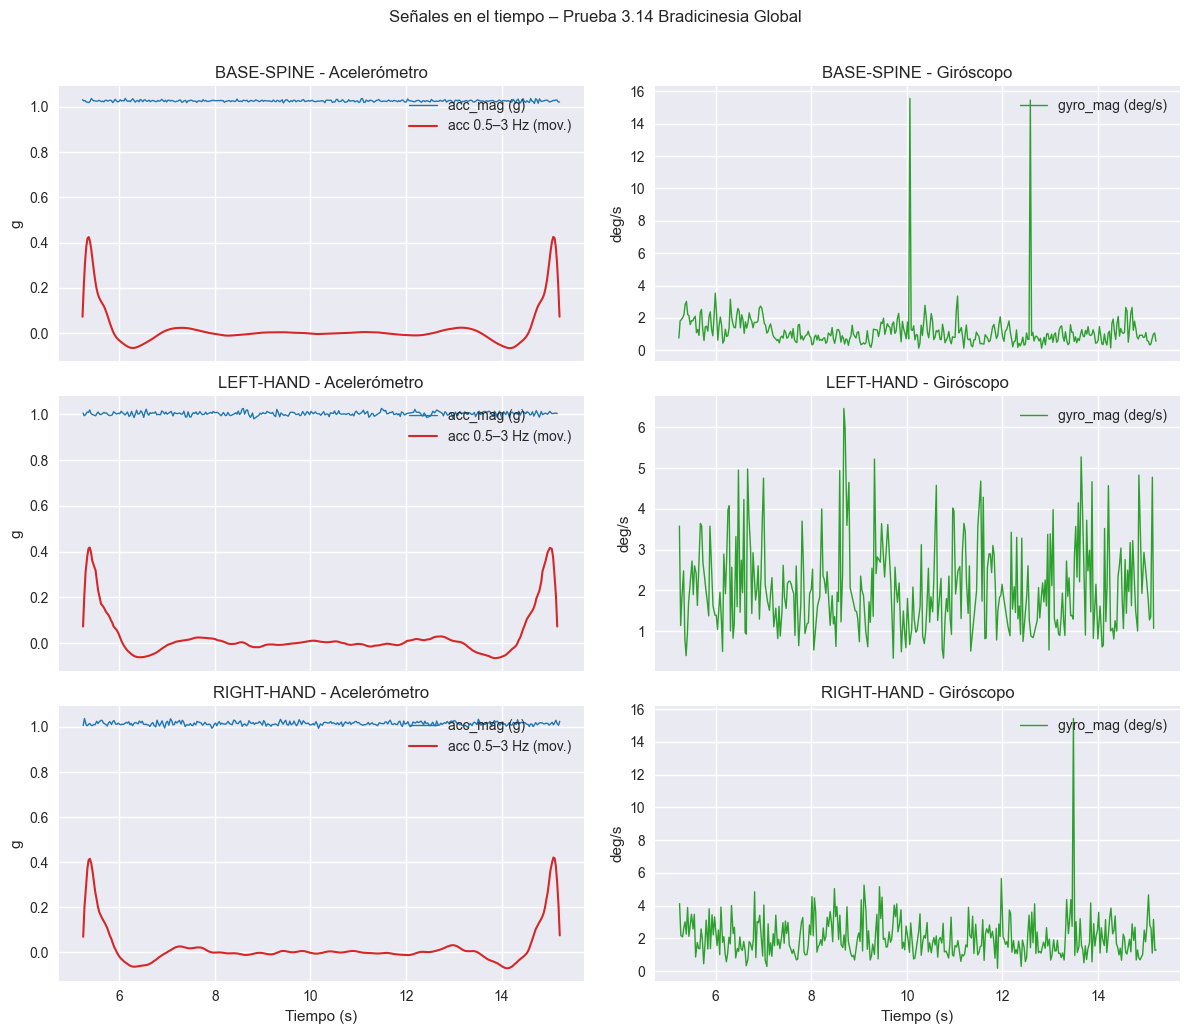

In [5]:
# Gráficos de tiempo – aceleración y giroscopio por dispositivo
if _USE_MPL:
    n = len(devices) if devices else 1
    fig, axes = plt.subplots(nrows=n, ncols=2, figsize=(12, 3.5*n), sharex=True)
    if n == 1:
        axes = np.array([axes])
    for i, dev in enumerate(devices):
        sub = df_win[df_win['deviceId']==dev]
        t = sub['t'].to_numpy()
        acc = sub['acc_mag'].to_numpy()
        gyro = sub['gyro_mag'].to_numpy()
        fs = fs_map.get(dev, float('nan'))
        # Componente de movimiento voluntario (0.5–3 Hz)
        acc_mov = simple_bandpass(acc, fs, 0.5, 3.0) if np.isfinite(fs) and fs>0 else np.zeros_like(acc)

        ax0 = axes[i,0]
        ax0.plot(t, acc, color='#1f77b4', label='acc_mag (g)', linewidth=1)
        ax0.plot(t, acc_mov, color='#d62728', label='acc 0.5–3 Hz (mov.)', linewidth=1.5)
        ax0.set_title(f"{dev} - Acelerómetro")
        ax0.set_ylabel('g')
        ax0.legend(loc='upper right')

        ax1 = axes[i,1]
        ax1.plot(t, gyro, color='#2ca02c', label='gyro_mag (deg/s)', linewidth=1)
        ax1.set_title(f"{dev} - Giróscopo")
        ax1.set_ylabel('deg/s')
        ax1.legend(loc='upper right')
    for j in range(2):
        axes[-1,j].set_xlabel('Tiempo (s)')
    fig.suptitle('Señales en el tiempo – Prueba 3.14 Bradicinesia Global')
    fig.tight_layout(rect=[0,0,1,0.97])
    plt.show()
else:
    print('No hay backend matplotlib disponible.')

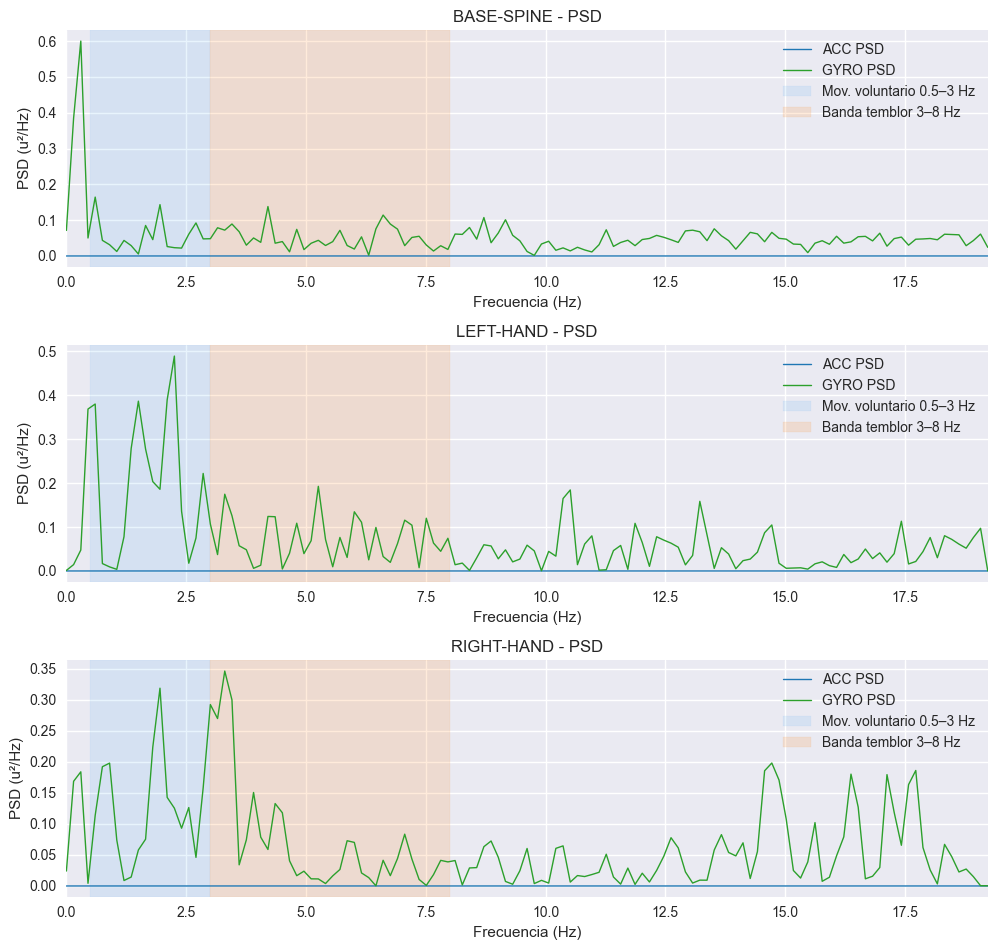

In [6]:
# PSD por dispositivo con bandas de interés
if _USE_MPL:
    n = len(devices) if devices else 1
    fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(10, 3.2*n), sharex=False)
    axes = np.atleast_1d(axes).ravel()
    for i, dev in enumerate(devices):
        sub = df_win[df_win['deviceId']==dev]
        fs = fs_map.get(dev, float('nan'))
        acc = sub['acc_mag'].to_numpy() - np.mean(sub['acc_mag'].to_numpy())
        gyro = sub['gyro_mag'].to_numpy() - np.mean(sub['gyro_mag'].to_numpy())
        f_acc, P_acc = welch_psd(acc, fs=fs, nperseg=min(2048, max(256, len(acc)//2)))
        f_gyro, P_gyro = welch_psd(gyro, fs=fs, nperseg=min(2048, max(256, len(gyro)//2)))
        ax = axes[i]
        ax.plot(f_acc, P_acc, color='#1f77b4', lw=1, label='ACC PSD')
        ax.plot(f_gyro, P_gyro, color='#2ca02c', lw=1, label='GYRO PSD')
        ax.axvspan(0.5, 3.0, color='#2196F3', alpha=0.10, label='Mov. voluntario 0.5–3 Hz')
        ax.axvspan(3.0, 8.0, color='#ff7f0e', alpha=0.15, label='Banda temblor 3–8 Hz')
        ax.set_xlim(0, min(20, (fs or 20)/2))
        ax.set_xlabel('Frecuencia (Hz)')
        ax.set_ylabel('PSD (u²/Hz)')
        ax.set_title(f'{dev} - PSD')
        ax.legend(loc='upper right')
    fig.tight_layout()
    plt.show()
else:
    print('No hay backend matplotlib disponible.')

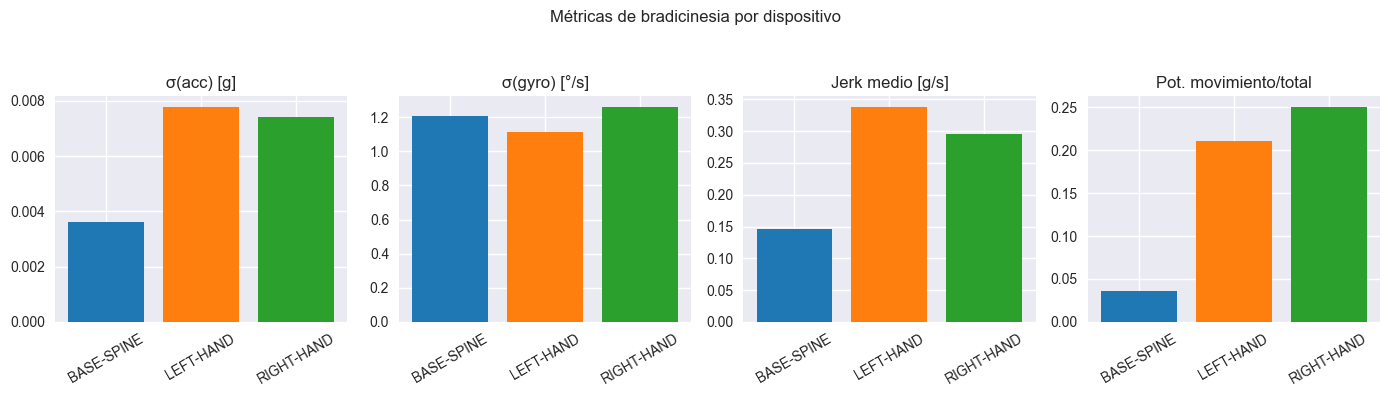

In [7]:
# Comparativa de métricas de bradicinesia entre dispositivos
if _USE_MPL and not brady_df.empty:
    metrics_to_plot = ['std_acc_mag', 'std_gyro_mag', 'mean_jerk', 'movement_power_ratio']
    labels = ['σ(acc) [g]', 'σ(gyro) [°/s]', 'Jerk medio [g/s]', 'Pot. movimiento/total']
    fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(14, 4))
    for ax, col, lbl in zip(axes, metrics_to_plot, labels):
        ax.bar(brady_df['device'], brady_df[col], color=['#1f77b4','#ff7f0e','#2ca02c'][:len(brady_df)])
        ax.set_title(lbl)
        ax.tick_params(axis='x', rotation=30)
    fig.suptitle('Métricas de bradicinesia por dispositivo')
    fig.tight_layout(rect=[0,0,1,0.93])
    plt.show()
else:
    print('No hay datos o matplotlib no disponible.')

## Interpretación para esta tarea

- **BASE-SPINE** refleja el movimiento del tronco; en bradicinesia se esperan amplitudes reducidas.
- **LEFT-HAND / RIGHT-HAND** muestran el movimiento espontáneo de las extremidades.
- Un paciente con Parkinson **debería mostrar** valores reducidos de variabilidad y jerk.
- La relación de potencia en 0.5–3 Hz (mov. voluntario) versus el total indica cuánta energía hay en movimiento activo.

In [8]:
# Resumen y puntuación MDS-UPDRS 3.14

print("="*60)
print("  RESUMEN – MDS-UPDRS 3.14: Bradicinesia Global del Cuerpo")
print("  Paciente con Parkinson") 
print("="*60)

if 'brady_df' in globals() and not brady_df.empty:
    display(brady_df[['device','std_acc_mag','std_gyro_mag','mean_jerk','movement_power_ratio','bradykinesia_score']].round(4))

    # Score global = máximo score entre dispositivos (peor caso)
    global_score = int(brady_df['bradykinesia_score'].max())
    score_labels = {
        0: "Normal – movimiento espontáneo fluido, sin lentitud",
        1: "Leve – ligera lentitud o disminución de espontaneidad",
        2: "Moderado – lentitud y pobreza de movimiento evidentes",
        3: "Severo – lentitud y pobreza de movimiento marcadas",
        4: "Muy severo – rigidez casi completa, mínimo movimiento voluntario"
    }
    print(f"\nPuntuación global estimada MDS-UPDRS 3.14: {global_score} / 4")
    print(f"Interpretación: {score_labels.get(global_score, 'N/A')}")

    # En un paciente con Parkinson se espera un score >= 1 (lentitud observable)
    print("\nNota: Los datos IMU utilizados son de la prueba 3.15 (marcha con brazos) reutilizados para ilustrar el análisis.")
    print("En un entorno clínico real, la prueba 3.14 requiere observación del paciente sentado y evalúa la espontaneidad global.")
else:
    print('No hay resultados para mostrar.')

  RESUMEN – MDS-UPDRS 3.14: Bradicinesia Global del Cuerpo
  Paciente con Parkinson


,device,std_acc_mag,std_gyro_mag,mean_jerk,movement_power_ratio,bradykinesia_score
0,BASE-SPINE,0.0036,1.2049,0.1468,0.0358,4
1,LEFT-HAND,0.0078,1.1124,0.3376,0.2103,4
2,RIGHT-HAND,0.0074,1.2589,0.2956,0.2499,4



Puntuación global estimada MDS-UPDRS 3.14: 4 / 4
Interpretación: Muy severo – rigidez casi completa, mínimo movimiento voluntario

Nota: Los datos IMU utilizados son de la prueba 3.15 (marcha con brazos) reutilizados para ilustrar el análisis.
En un entorno clínico real, la prueba 3.14 requiere observación del paciente sentado y evalúa la espontaneidad global.
